In [131]:
# "CafeMind"
###"Learning buying patterns — one sale at a time."
###"Smart predictions from simple orders."

In [ ]:
#Name: Munazza Anwar F2023266508
#     Batool F2023266523

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [157]:
df = pd.read_csv("dirty_cafe_sales.csv")

In [159]:
print(df.shape)  

(10000, 8)


In [161]:
print(df.columns)  

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')


In [163]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [165]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
print(df.columns)

Index(['Transaction_ID', 'Item', 'Quantity', 'Price_Per_Unit', 'Total_Spent',
       'Payment_Method', 'Location', 'Transaction_Date'],
      dtype='object')


In [167]:
print(df.dtypes)

Transaction_ID      object
Item                object
Quantity            object
Price_Per_Unit      object
Total_Spent         object
Payment_Method      object
Location            object
Transaction_Date    object
dtype: object


In [169]:
print(df.info())     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction_ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price_Per_Unit    9821 non-null   object
 4   Total_Spent       9827 non-null   object
 5   Payment_Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction_Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB
None


In [171]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    10000 non-null  object        
 1   Item              9667 non-null   object        
 2   Quantity          9862 non-null   object        
 3   Price_Per_Unit    9821 non-null   object        
 4   Total_Spent       9827 non-null   object        
 5   Payment_Method    7421 non-null   object        
 6   Location          6735 non-null   object        
 7   Transaction_Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(7)
memory usage: 625.1+ KB
None


In [173]:
print(df.isnull().sum())

Transaction_ID         0
Item                 333
Quantity             138
Price_Per_Unit       179
Total_Spent          173
Payment_Method      2579
Location            3265
Transaction_Date     460
dtype: int64


In [175]:
df['Item'] = df['Item'].fillna('Unknown')
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')
df['Location'] = df['Location'].fillna('Unknown')

# Convert to numeric
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price_Per_Unit'] = pd.to_numeric(df['Price_Per_Unit'], errors='coerce')
df['Total_Spent'] = pd.to_numeric(df['Total_Spent'], errors='coerce')

# Fill missing Quantity and Price_Per_Unit with 0
df['Quantity'] = df['Quantity'].fillna(0)
df['Price_Per_Unit'] = df['Price_Per_Unit'].fillna(0)

# Fill missing Total_Spent by calculating it
df['Total_Spent'] = df['Total_Spent'].fillna(df['Quantity'] * df['Price_Per_Unit'])

# 
df['Transaction_Date'] = df['Transaction_Date'].fillna('Unknown')

print(df)

     Transaction_ID      Item  Quantity  Price_Per_Unit  Total_Spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          4.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
...             ...       ...       ...             ...          ...   
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9996    TXN_9659401   Unknown       3.0             0.0          3.0   
9997    TXN_5255387    Coffee       4.0             2.0          8.0   
9998    TXN_7695629    Cookie       3.0             0.0          3.0   
9999    TXN_6170729  Sandwich       3.0             4.0         12.0   

      Payment_Method  Location     Transaction_Date  
0        Credit Card  Takeaway  2023-09-08 00:00:00  
1               Cash  In-st

In [177]:
df.isnull().sum()

Transaction_ID      0
Item                0
Quantity            0
Price_Per_Unit      0
Total_Spent         0
Payment_Method      0
Location            0
Transaction_Date    0
dtype: int64

In [179]:
df_cleaned = df.copy()

df_cleaned.describe()

,Quantity,Price_Per_Unit,Total_Spent
count,10000.000000,10000.000000,10000.000000
mean,2.883400,2.792750,8.895200
std,1.528214,1.409422,6.018911
min,0.000000,0.000000,0.000000
25%,2.000000,1.500000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [181]:
bad_values = ['UNKNOWN', 'Unknown', 'ERROR']
print(df_cleaned['Item'].value_counts().loc[bad_values])


Item
UNKNOWN    344
Unknown    333
ERROR      292
Name: count, dtype: int64


In [183]:
df_cleaned['Item'] = df_cleaned['Item'].replace(['UNKNOWN', 'Unknown', 'ERROR'], 'Unspecified')

### Cleaning the 'Item' Column:

#We found 969 rows with invalid item names (`'UNKNOWN'`, `'Unknown'`, and `'ERROR'`).  
#Instead of deleting them or guessing, we replaced them with `'Unspecified'` to preserve the data and allow separate analysis if needed.


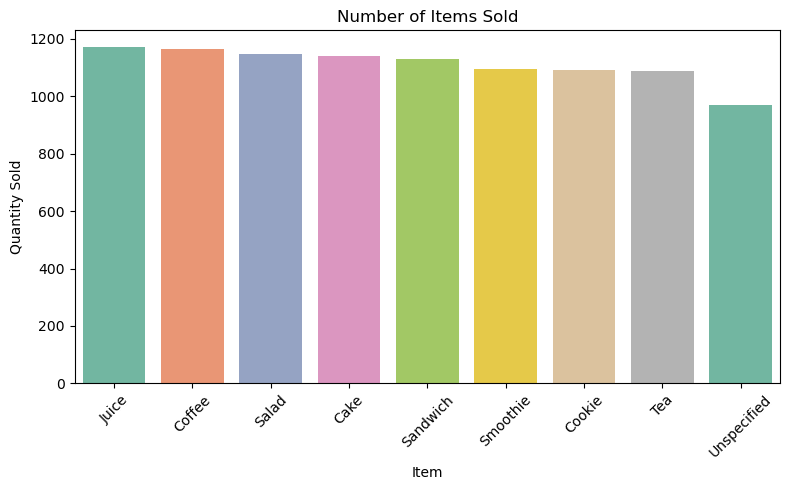

In [185]:
item_counts = df_cleaned['Item'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=item_counts.index, y=item_counts.values, hue=item_counts.index, palette='Set2', legend=False)
plt.title('Number of Items Sold')
plt.xlabel('Item')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

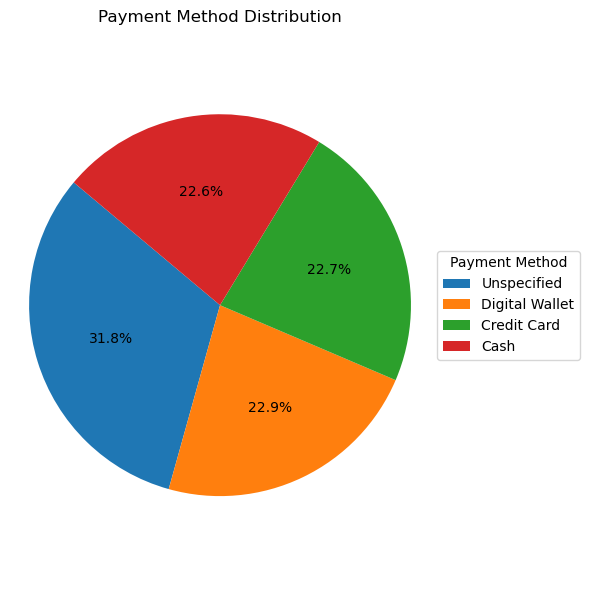

In [187]:
df_cleaned['Payment_Method'] = df_cleaned['Payment_Method'].replace(['UNKNOWN', 'Unknown', 'ERROR'], 'Unspecified')
payment_counts = df_cleaned['Payment_Method'].value_counts()

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(payment_counts, labels=None, autopct='%1.1f%%', startangle=140)
plt.legend(wedges, payment_counts.index, title="Payment Method", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('Payment Method Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

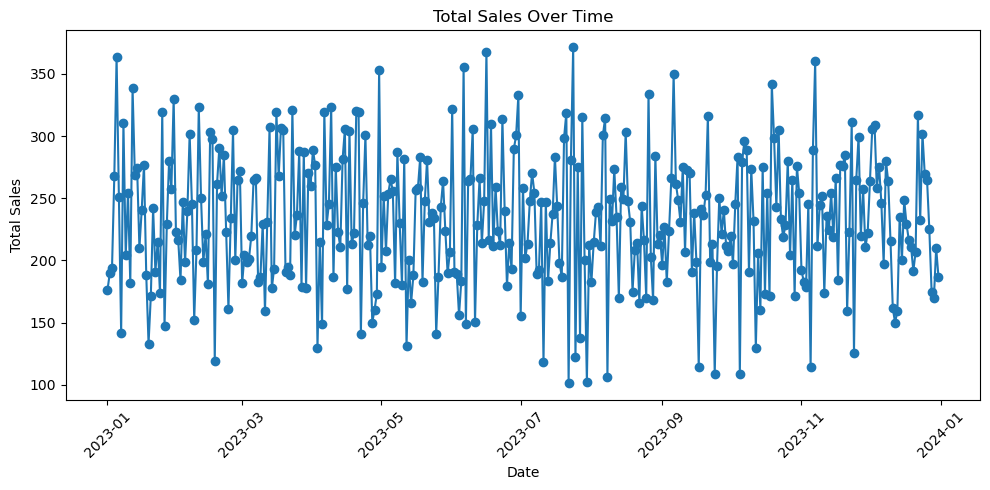

In [189]:
# Ensure 'Transaction_Date' is in datetime format and clean
df_cleaned['Transaction_Date'] = pd.to_datetime(df_cleaned['Transaction_Date'], errors='coerce')

# Drop rows with invalid dates (NaT)
df_cleaned = df_cleaned.dropna(subset=['Transaction_Date'])

# Sort safely without inplace to avoid SettingWithCopyWarning
df_cleaned = df_cleaned.sort_values('Transaction_Date')

# Group by date and sum total sales
daily_sales = df_cleaned.groupby('Transaction_Date')['Total_Spent'].sum()

# Plot line graph of total sales over time
plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales.values, marker='o')
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


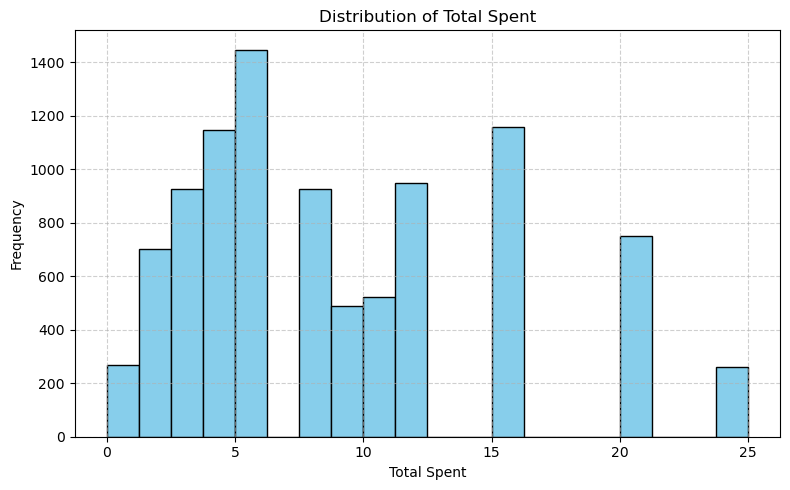

In [191]:
plt.figure(figsize=(8, 5))
plt.hist(df_cleaned['Total_Spent'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


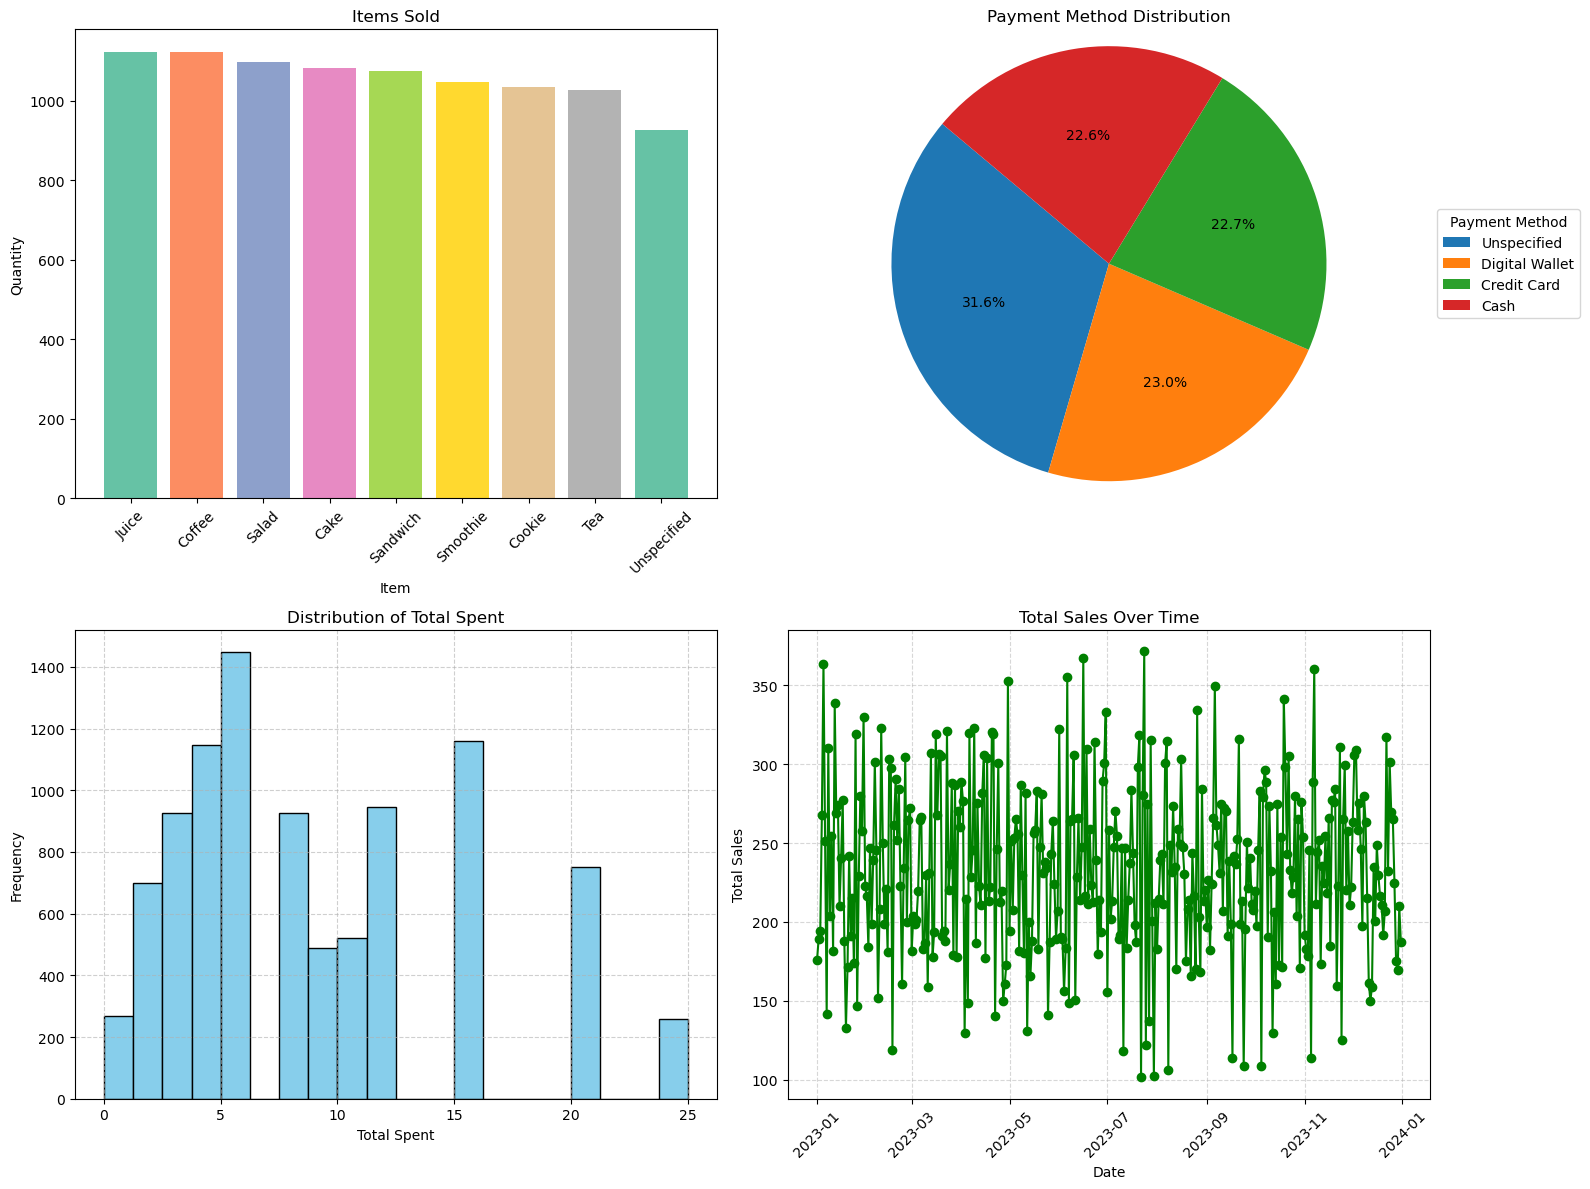

In [193]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --- Bar Plot ---
item_counts = df_cleaned['Item'].value_counts()
bars = axs[0, 0].bar(item_counts.index, item_counts.values, color=plt.cm.Set2.colors)
axs[0, 0].set_title('Items Sold')
axs[0, 0].set_xlabel('Item')
axs[0, 0].set_ylabel('Quantity')
axs[0, 0].tick_params(axis='x', rotation=45)

# --- Pie Chart ---
payment_counts = df_cleaned['Payment_Method'].value_counts()
wedges, texts, autotexts = axs[0, 1].pie(payment_counts, labels=None, autopct='%1.1f%%', startangle=140)
axs[0, 1].legend(wedges, payment_counts.index, title="Payment Method", loc="center left", bbox_to_anchor=(1, 0.5))
axs[0, 1].set_title('Payment Method Distribution')
axs[0, 1].axis('equal')

# --- Histogram ---
axs[1, 0].hist(df_cleaned['Total_Spent'], bins=20, color='skyblue', edgecolor='black')
axs[1, 0].set_title('Distribution of Total Spent')
axs[1, 0].set_xlabel('Total Spent')
axs[1, 0].set_ylabel('Frequency')
axs[1, 0].grid(True, linestyle='--', alpha=0.6)

# --- Line Plot ---
daily_sales = df_cleaned.groupby('Transaction_Date')['Total_Spent'].sum()
axs[1, 1].plot(daily_sales.index, daily_sales.values, marker='o', linestyle='-', color='green')
axs[1, 1].set_title('Total Sales Over Time')
axs[1, 1].set_xlabel('Date')
axs[1, 1].set_ylabel('Total Sales')
axs[1, 1].tick_params(axis='x', rotation=45)
axs[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


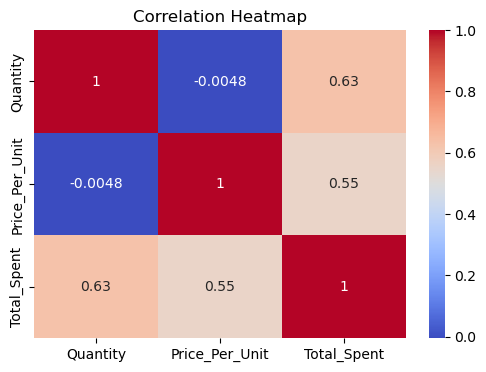

In [195]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_cleaned[['Quantity', 'Price_Per_Unit', 'Total_Spent']].corr(), annot=True, cmap='coolwarm',)
plt.title('Correlation Heatmap')
plt.show()

In [197]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


In [199]:
le_payment = LabelEncoder()
le_location = LabelEncoder()
df_cleaned['Payment_Method_Code'] = le_payment.fit_transform(df_cleaned['Payment_Method'])
df_cleaned['Location_Code'] = le_location.fit_transform(df_cleaned['Location'])

In [201]:
X = df_cleaned[['Quantity', 'Price_Per_Unit', 'Total_Spent', 'Payment_Method_Code', 'Location_Code']]
y = df_cleaned['Item']

In [203]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [205]:
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train, y_train)
y_pred = knn_classifier.predict(X_test)


In [207]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

        Cake       0.50      0.73      0.59       205
      Coffee       0.85      0.97      0.91       232
      Cookie       0.87      0.97      0.92       215
       Juice       0.54      0.39      0.45       194
       Salad       0.89      0.97      0.93       237
    Sandwich       0.44      0.54      0.49       221
    Smoothie       0.41      0.37      0.39       196
         Tea       0.89      0.94      0.91       221
 Unspecified       0.12      0.02      0.03       187

    accuracy                           0.68      1908
   macro avg       0.61      0.65      0.62      1908
weighted avg       0.63      0.68      0.64      1908



In [209]:
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:

[[149   1   0  51   0   2   1   0   1]
 [  2 225   0   0   0   0   0   4   1]
 [  0   1 209   0   0   0   0   4   1]
 [114   0   1  75   0   2   1   0   1]
 [  0   0   0   0 229   1   3   0   4]
 [  3   0   0   1   4 120  89   0   4]
 [  2   0   0   0   0 116  72   0   6]
 [  1   5   2   0   0   1   0 207   5]
 [ 30  32  27  12  24  31  10  18   3]]


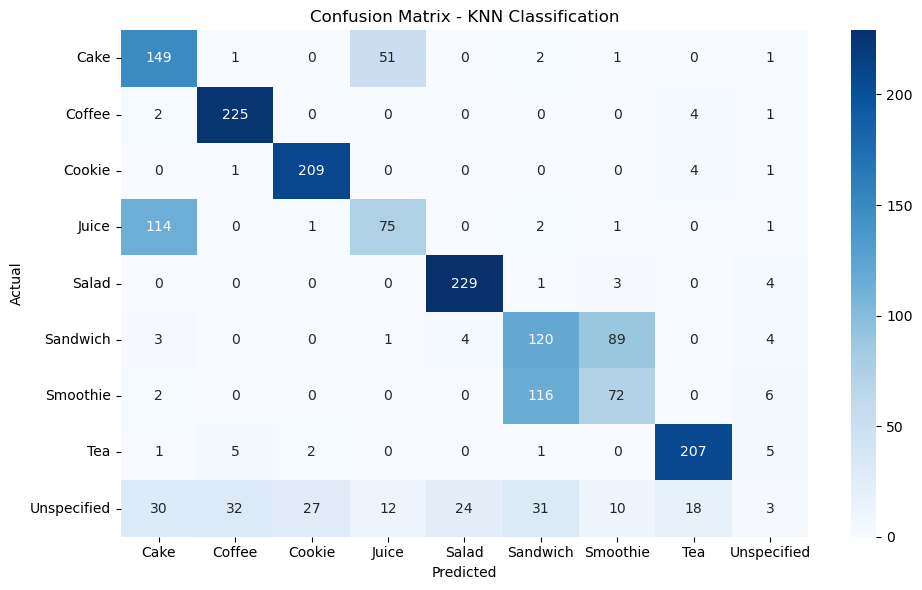

In [211]:
cm = confusion_matrix(y_test, y_pred, labels=knn_classifier.classes_)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=knn_classifier.classes_, yticklabels=knn_classifier.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN Classification')
plt.tight_layout()
plt.show()

In [213]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 67.56%


In [215]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=3)

In [217]:
y_pred = model.predict(X_test)

In [219]:
prediction_results = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': y_pred[:10]
})
prediction_results


,Actual,Predicted
0,Unspecified,Smoothie
1,Unspecified,Salad
2,Tea,Tea
3,Cookie,Cookie
4,Cookie,Cookie
5,Sandwich,Sandwich
6,Juice,Juice
7,Cake,Cake
8,Sandwich,Smoothie
9,Coffee,Coffee


In [225]:
# Use same column names as X_train
feature_names = X_train.columns

# Create DataFrame with correct structure
new_input_df = pd.DataFrame([[2, 3.5, 7.0, 1, 0]], columns=feature_names)

prediction = model.predict(new_input_df)
print("Predicted class:", prediction[0])


Predicted class: Juice
